In [1]:
import pandas as pd

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import seaborn as sns

import numpy as np




In [5]:
import ast

#orig_df=pd.read_csv("Human_Sentiment_Agree.csv")

#falcon_df=pd.read_csv("HSA_Faclon_Pred_Gen.csv")

aug_df=pd.read_csv("HSA_Faclon_Pred_Nuc.csv")
print(aug_df.columns)
aug_df = aug_df.rename(columns={'Falcon_Pred': 'Pred'})

#print(aug_df.head())

def extract_label(json_str):
    try:
        # Convert string to a Python object (list of dictionaries)
        json_obj = ast.literal_eval(json_str)
        if isinstance(json_obj, list) and len(json_obj) > 0 and 'label' in json_obj[0]:
            return json_obj[0]['label']
    except (ValueError, SyntaxError):
        print(json_obj)
        return None  # Return None if parsing fails
    return None  # Return None if format is incorrect


#falcon_df['Falcon_Pred'] =falcon_df['Falcon_Pred'].apply(extract_label)
aug_df['Pred'] = aug_df['Pred'].apply(extract_label)

mapping_1={'positive':1,'negative':-1, 'neutral':0}

mapping_2={'Positive':1,'Negative':-1, 'Neutral':0}

#falcon_df['Falcon_Pred'] = falcon_df['Falcon_Pred'].replace(mapping_1)

aug_df['Pred'] = aug_df['Pred'].replace(mapping_1)

aug_df['Sentiment'] = aug_df['Sentiment'].replace(mapping_2)

Index(['Unnamed: 0', 'Unnamed: 0.1', 'Tweets', 'Sentiment', 'Sarcasm_Col',
       'Topic', 'Falcon_Pred'],
      dtype='object')


In [6]:
aug_df_f1 = aug_df[((aug_df['Sentiment'] != aug_df['Pred']) & (aug_df['Sarcasm_Col'] == 'Sarcastic'))]

print(aug_df_f1.shape)

aug_df = aug_df[~((aug_df['Sentiment'] != aug_df['Pred']) & (aug_df['Sarcasm_Col'] == 'Sarcastic'))]

df2=pd.read_csv("Sarc_Aug_Gen_Mistral_Pred.csv")

df2 = df2[df2['Tweets'].isin(aug_df_f1['Tweets'])]
df2 = df2.rename(columns={'Mistral_Pred': 'Pred'})

(1765, 7)


In [7]:
aug_df=aug_df[['Tweets', 'Sentiment', 'Sarcasm_Col','Topic', 'Pred']]

In [8]:
df2=df2[['Tweets', 'Sentiment', 'Sarcasm_Col', 'Topic', 'Sarcasm_Aug','Pred']]

mapping_1={'Positive':1,'Negative':-1, 'Neutral':0}

df2['Sentiment'] = df2['Sentiment'].replace(mapping_1)

df2['Pred'] = df2['Pred'].apply(extract_label)

mapping_1={'positive':1,'negative':-1, 'neutral':0}

df2['Pred'] = df2['Pred'].replace(mapping_1)

In [16]:
df2['Pred'].unique()

array([-1,  1,  0])

In [9]:
aug_df = pd.concat([aug_df, df2], axis=0, ignore_index=True)

0.6787345626797496


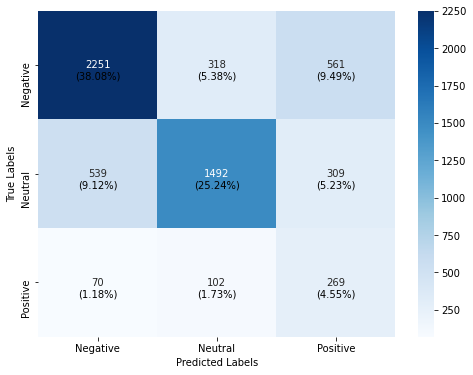

In [10]:
c=0
for index,row in aug_df.iterrows():
    if row['Sentiment']==row['Pred']:
        c+=1

print(c/aug_df.shape[0])

mapping={1:'Positive',-1:'Negative',0:'Neutral'}

aug_df['Sentiment']=aug_df['Sentiment'].replace(mapping)

aug_df['Pred']=aug_df['Pred'].replace(mapping)

labels = ["Negative","Neutral", "Positive"]

cm = confusion_matrix(aug_df['Sentiment'], aug_df['Pred'])

# Compute percentages
cm_percentage = cm.astype('float') / cm.sum() * 100

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

# Adding percentage annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j + 0.5, i + 0.55, f"\n({cm_percentage[i, j]:.2f}%)",
                 ha='center', va='center', color='black', fontsize=10)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
#plt.title("Confusion Matrix")
#plt.show()
plt.savefig('falcon_nuc_hl_aug.png', dpi=1200)

In [44]:
aug_df['Falcon_Pred'].unique()

array([-1, 0, 1, ...,
       "[{'label': 'neutral', 'score': 0.9996010661125183}]",
       "[{'label': 'negative', 'score': 0.999200165271759}]",
       "[{'label': 'positive', 'score': 0.9997633099555969}]"],
      dtype=object)

In [60]:
aug_df=pd.read_csv("HSA_Faclon_Pred_Gen.csv")
print(aug_df.columns)
aug_df = aug_df.rename(columns={'Falcon_Pred': 'Pred'})

#print(aug_df.head())

def extract_label(json_str):
    try:
        # Convert string to a Python object (list of dictionaries)
        json_obj = ast.literal_eval(json_str)
        if isinstance(json_obj, list) and len(json_obj) > 0 and 'label' in json_obj[0]:
            return json_obj[0]['label']
    except (ValueError, SyntaxError):
        print(json_obj)
        return None  # Return None if parsing fails
    return None  # Return None if format is incorrect


#falcon_df['Falcon_Pred'] =falcon_df['Falcon_Pred'].apply(extract_label)
aug_df['Pred'] = aug_df['Pred'].apply(extract_label)

mapping_1={'positive':1,'negative':-1, 'neutral':0}

mapping_2={'Positive':1,'Negative':-1, 'Neutral':0}

#falcon_df['Falcon_Pred'] = falcon_df['Falcon_Pred'].replace(mapping_1)

aug_df['Pred'] = aug_df['Pred'].replace(mapping_1)

aug_df['Sentiment'] = aug_df['Sentiment'].replace(mapping_2)

d_sarc={"C":0,"NC":0}

d_nsarc={"C":0,"NC":0}

for index,row in aug_df.iterrows():
    
    if row['Sarcasm_Col']=="Sarcastic":
        if row['Sentiment']==row['Pred']:
            d_sarc["C"]+=1
        else:
            d_sarc["NC"]+=1
    else:
        if row['Sentiment']==row['Pred']:
            d_nsarc["C"]+=1
        else:
            d_nsarc["NC"]+=1
        

Index(['Unnamed: 0', 'Unnamed: 0.1', 'Tweets', 'Sentiment', 'Sarcasm_Col',
       'Topic', 'Falcon_Pred'],
      dtype='object')


In [61]:
print(d_sarc)

print(d_nsarc)

{'C': 1580, 'NC': 988}
{'C': 1024, 'NC': 2337}


In [92]:
df1=pd.read_csv("Human_Sentiment_Agree.csv")

df2=pd.read_csv("results_llama2.csv")



In [64]:
print(df1.columns)

Index(['Unnamed: 0', 'Tweets', 'Sentiment', 'Sarcasm_Col', 'Topic'], dtype='object')


In [68]:
df2 = df2.rename(columns={'Label': 'llama_Label'})

df2 = df2.rename(columns={'Tweet': 'Tweets'})

In [69]:
print(df1.shape)

merged_df = pd.merge(df1, df2, on='Tweets')

print(merged_df.shape)

(5929, 5)
(5929, 8)


In [70]:
merged_df.head()

,Unnamed: 0_x,Tweets,Sentiment,Sarcasm_Col,Topic,Unnamed: 0_y,llama_Label,Score
0,0,"""Oh, yay for me! I've been living a mere 10 km...",-1,Sarcastic,Energy,0,positive,1.000000
1,3,Also concern me electric vehicles: The grid wo...,0,Non-Sarcastic,Energy,1,negative,0.997770
2,5,"""Israel's Prime Minister finally decides to ca...",0,Sarcastic,Politics,2,neutral,0.999870
3,9,"""Wow, big round of applause to for firing yet ...",-1,Sarcastic,Politics,3,positive,0.999997
4,10,"""Oh no, what a shocker! Looks like the US migh...",-1,Sarcastic,Politics,4,negative,0.999996


In [71]:
mapping_1={'positive':1,'negative':-1, 'neutral':0}

merged_df['llama_Label'] = merged_df['llama_Label'].replace(mapping_1)

In [86]:
d_sarc={"C":0,"NC":0}

d_nsarc={"C":0,"NC":0}

for index,row in merged_df.iterrows():
    
    if row['Sarcasm_Col']=="Sarcastic":
        if row['Sentiment']==row['llama_Label']:
            d_sarc["C"]+=1
        else:
            d_sarc["NC"]+=1
    else:
        if row['Sentiment']==row['llama_Label']:
            d_nsarc["C"]+=1
        else:
            d_nsarc["NC"]+=1
            
print(d_sarc)

print(d_nsarc)

{'C': 947, 'NC': 1621}
{'C': 2168, 'NC': 1193}


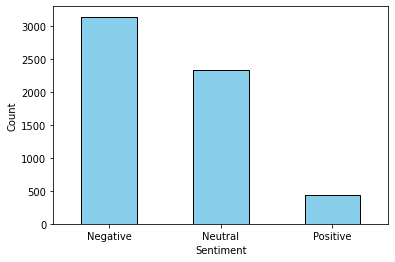

In [93]:
#df1 = df1[df1['Sarcasm_Col'] == 'Sarcastic']
mapping_1={1:'Positive',-1:'Negative', 0:'Neutral'}
df1['Sentiment'] = df1['Sentiment'].replace(mapping_1)
value_counts = df1['Sentiment'].value_counts()
# Plot using Matplotlib
plt.figure(figsize=(6, 4))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
#plt.title("Category Counts")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
#plt.grid(axis='y', alpha=0.7)

# Show plot
#plt.show()
plt.savefig("HSA_Sentiment.png")

<Figure size 432x288 with 0 Axes>

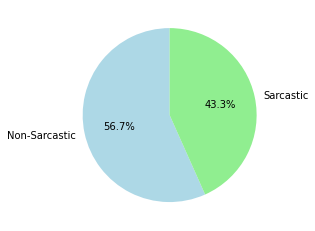

In [94]:
value_counts = df1['Sarcasm_Col'].value_counts()
value_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen'])
plt.ylabel("")  # Hide y-label
#plt.title("Category Distribution")#
#plt.show()
plt.savefig("HSA_Sarcasm_Dist.png")

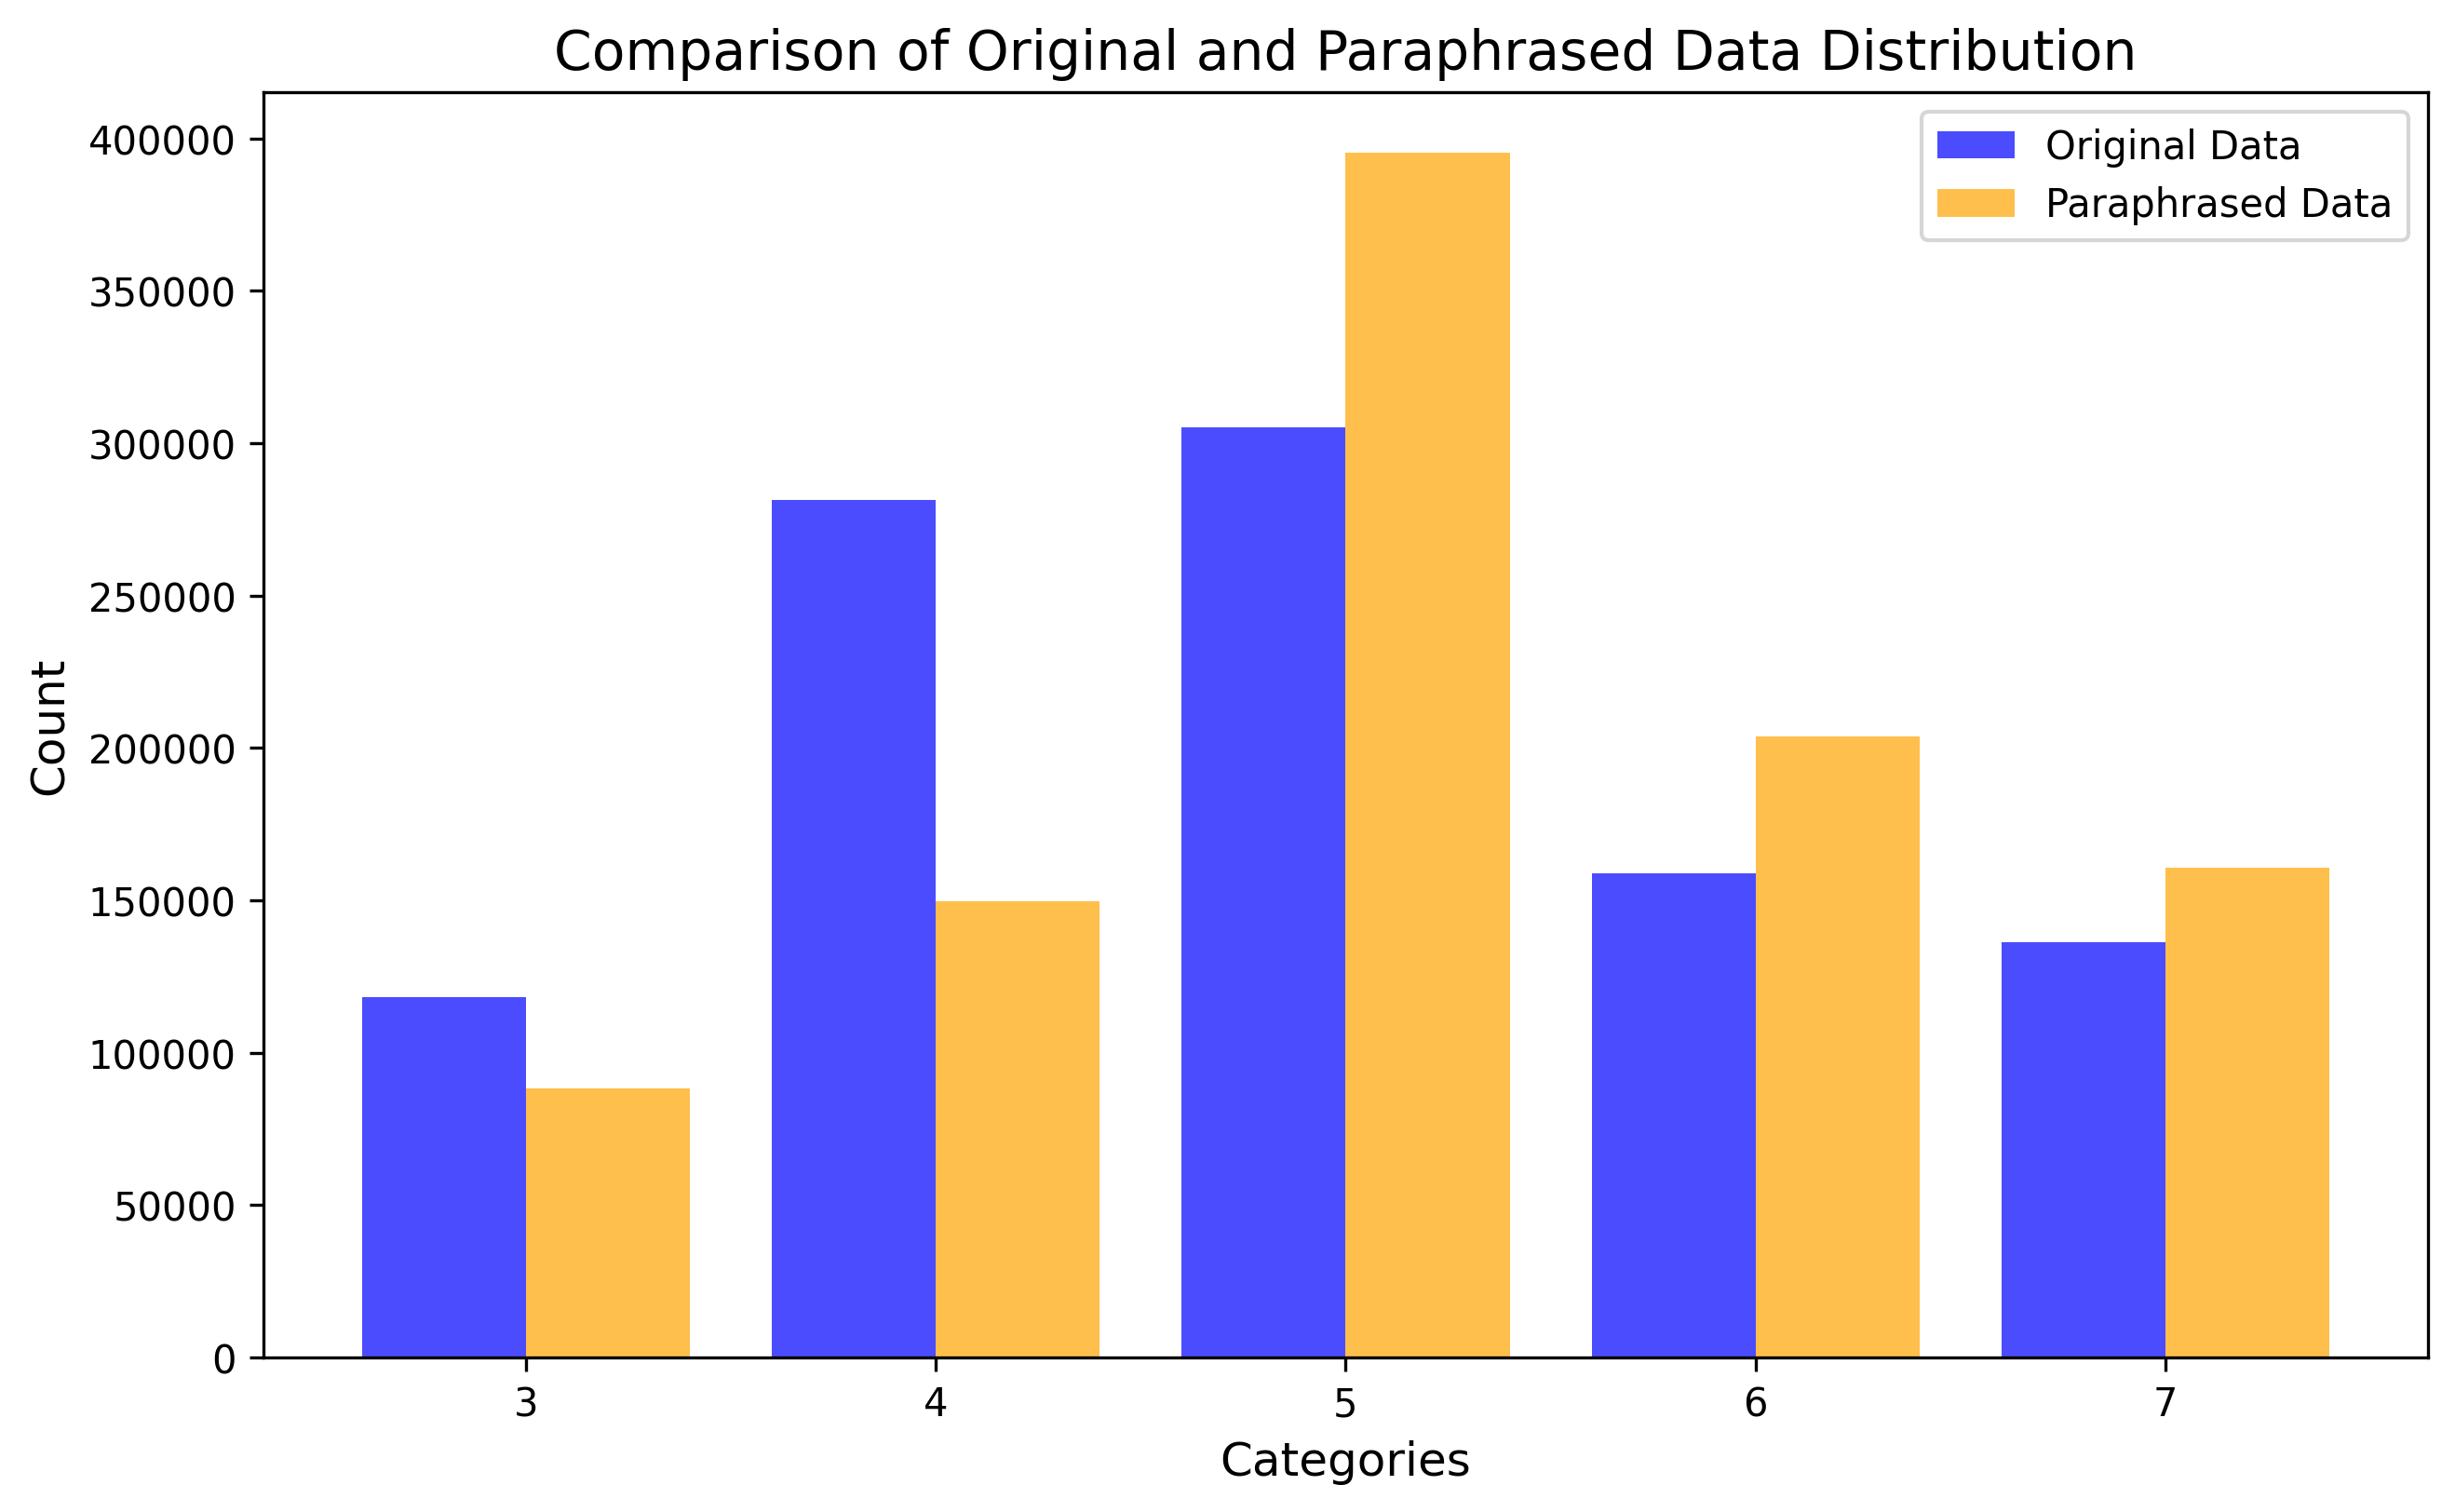

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = [3, 4, 5, 6, 7]
original_counts = [118375, 281259, 305179, 158987, 136200]
new_counts = [88347, 149728, 395363, 203801, 160628]

# Bar width
bar_width = 0.4
x = np.arange(len(categories))

# Plot bars
plt.figure(figsize=(10, 6), dpi=300)
plt.bar(x - bar_width / 2, original_counts, width=bar_width, label="Original Data", color="blue", alpha=0.7)
plt.bar(x + bar_width / 2, new_counts, width=bar_width, label="Paraphrased Data", color="orange", alpha=0.7)

# Labels and title
plt.xlabel("Categories", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Comparison of Original and Paraphrased Data Distribution", fontsize=14)
plt.xticks(x, categories)
plt.legend()

# Show grid
#plt.grid(axis='y', linestyle="--", alpha=0.7)

# Save high-resolution image
plt.savefig("Paraphase_data_distribution_comparison.png", dpi=300, bbox_inches="tight")

# Show plot
#plt.show()
